# MNIST Digit Classification using CNN
This code calculates three common cost functions to evaluate the performance of the trained model:

Root Mean Squared Error (RMSE): This metric measures the average magnitude of the errors. It calculates the square root of the average of the squared differences between predicted and actual values. A lower RMSE indicates a better fit of the model to the data.
Mean Absolute Error (MAE): This metric measures the average magnitude of the errors without considering their direction. It's the average of the absolute differences between predictions and actual observations. Like RMSE, a lower MAE indicates better model performance.
Categorical Cross-entropy: This is a loss function commonly used in multi-class classification problems, where the true labels are one-hot encoded. The loss variable used here was already calculated during the model evaluation step and represents this metric. A lower categorical cross-entropy indicates that the model's predicted probability distribution is closer to the true distribution.

## Load and preprocess the mnist dataset

### Subtask:
Load the dataset and perform necessary preprocessing steps, such as normalization and reshaping.


**Reasoning**:
The subtask requires loading and preprocessing the MNIST dataset, which involves loading the data, splitting into training and testing sets, normalizing, reshaping, and one-hot encoding the labels. These steps can be grouped into a single code block.



In [ ]:
import tensorflow as tf

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 3. Normalize the image data
x_train = x_train / 255.0
x_test = x_test / 255.0

# 4. Reshape the image data to include a channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# 5. Convert the labels to one-hot encoded vectors
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print("Preprocessing complete.")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Preprocessing complete.
x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
x_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


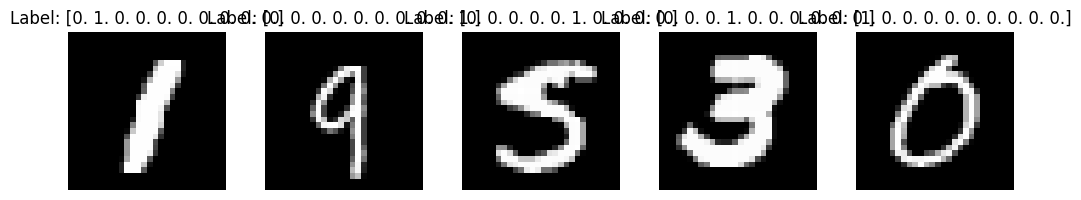

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 5 random indices
random_indices = np.random.randint(0, len(x_train), 5)

# Create figure and subplots
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

# Iterate and display images
for i, index in enumerate(random_indices):
    image = x_train[index].squeeze()  # Remove channel dimension
    label = y_train[index]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

# Adjust layout and display plot
plt.tight_layout()
plt.show()

## Build the cnn model

### Subtask:
Define the architecture of the CNN model using TensorFlow/Keras.


**Reasoning**:
Define the CNN model architecture using Keras Sequential API as instructed, including convolutional, pooling, flatten, dense, dropout, and output layers.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 3. Instantiate a Sequential model
model = Sequential()

# 4. Add convolutional layers
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))

# 5. Add pooling layers
model.add(MaxPooling2D(pool_size=(2, 2)))

# 8. Add a dropout layer
model.add(Dropout(0.25))

# 6. Add a Flatten layer
model.add(Flatten())

# 7. Add dense (fully connected) layers
model.add(Dense(128, activation='relu'))

# 8. Add a dropout layer
model.add(Dropout(0.5))

# 9. Add the output layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

### Subtask:
Compile the model with an appropriate optimizer, loss function (categorical cross-entropy for multi-class classification), and metrics.


**Reasoning**:
Compile the defined model with the specified optimizer, loss function, and metrics.



In [ ]:
# 1. Compile the defined model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.


## Train the model

### Subtask:
Train the CNN model on the preprocessed training data.


**Reasoning**:
Train the compiled CNN model on the preprocessed training data and include validation data for monitoring.



In [ ]:
# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
print("Model training complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8860 - loss: 0.3687 - val_accuracy: 0.9838 - val_loss: 0.0444
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9747 - loss: 0.0856 - val_accuracy: 0.9889 - val_loss: 0.0307
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9828 - loss: 0.0565 - val_accuracy: 0.9908 - val_loss: 0.0294
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9843 - loss: 0.0495 - val_accuracy: 0.9883 - val_loss: 0.0371
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9883 - loss: 0.0408 - val_accuracy: 0.9920 - val_loss: 0.0278
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.9911 - val_loss: 0.0325
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9895 - loss: 0.0315 - val_accuracy: 0.9910 - val_loss: 0.0308
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9916 - loss: 0.028

## Evaluate the model

### Subtask:
Evaluate the trained model on the test data and calculate the specified evaluation metrics (accuracy, precision, recall, F1 score, confusion matrix).

**Reasoning**:
Evaluate the trained model on the test data and calculate accuracy, precision, recall, F1 score, and confusion matrix using appropriate libraries.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# 1. Evaluate the model on the test data
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

# 2. Get predictions for the test data
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Calculate evaluation metrics
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print('Confusion Matrix:')
display(conf_matrix)

Test loss: 0.0302
Test accuracy: 0.9924
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Precision: 0.9924
Recall: 0.9924
F1 Score: 0.9924
Confusion Matrix:


array([[ 978,    0,    0,    1,    0,    0,    0,    0,    1,    0],
       [   0, 1131,    1,    0,    0,    2,    0,    1,    0,    0],
       [   1,    1, 1024,    1,    1,    0,    0,    4,    0,    0],
       [   0,    0,    0, 1008,    0,    1,    0,    0,    1,    0],
       [   1,    0,    0,    0,  975,    0,    1,    0,    1,    4],
       [   1,    0,    0,    8,    0,  881,    1,    0,    0,    1],
       [   5,    2,    1,    0,    2,    3,  943,    0,    2,    0],
       [   0,    2,    3,    0,    0,    0,    0, 1022,    1,    0],
       [   1,    1,    1,    1,    0,    0,    0,    1,  967,    2],
       [   0,    0,    0,    1,    3,    2,    0,    3,    5,  995]])

## Calculate cost functions

### Subtask:
Calculate the specified cost functions (RMSE, MAE, Categorical Cross-entropy) on the test data.

**Reasoning**:
Calculate the RMSE, MAE, and Categorical Cross-entropy using the true and predicted labels on the test data.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae:.4f}')

# Calculate Categorical Cross-entropy
# Note: Keras's evaluate already provides the loss which is Categorical Cross-entropy in this case
categorical_crossentropy = loss # The 'loss' variable was calculated in the previous evaluation step
print(f'Categorical Cross-entropy: {categorical_crossentropy:.4f}')

Root Mean Squared Error (RMSE): 0.0355
Mean Absolute Error (MAE): 0.0018
Categorical Cross-entropy: 0.0302
